# 🌍 Seismic Dataset Builder v2 — STA/LTA Intelligent Labeling

**Mejora principal v2:** Detección automática de ventanas sísmicas mediante el algoritmo **STA/LTA** (Short-Term Average / Long-Term Average), estándar en sismología operacional.

| Clase | Origen | Fuente |
|---|---|---|
| `0_Ruido` | Ruido sensor ADXL345 **+** silencio pre/post-sismo del SGC | `.bin` + `.anc` |
| `1_Sismo` | Segmentos disparados por STA/LTA (evento real) | `.anc` |

```
Señal SGC  ──────────────────────────────────────────────────────
                                  ┌──────────┐
STA/LTA    ─────────────────┄┄┄┄┄│  SISMO   │┄┄┄┄┄───────────────
                     trigger_on ──┘          └── trigger_off
Clase         ██████ 0_Ruido ████           ████ 0_Ruido ██████
```
---

## 0 — Imports y Configuración Global

In [2]:
import struct, os, glob, re, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.signal import spectrogram

# ObsPy STA/LTA (preferred)
try:
    from obspy.signal.trigger import classic_sta_lta, recursive_sta_lta, trigger_onset
    OBSPY_AVAILABLE = True
    print("✅ ObsPy disponible — usando classic_sta_lta")
except ImportError:
    OBSPY_AVAILABLE = False
    warnings.warn("ObsPy no disponible — se usará implementación NumPy")

# ════════════════════════════════════════════════════════════
#  PARÁMETROS GLOBALES — modifica aquí antes de procesar
# ════════════════════════════════════════════════════════════

# ── Sensor / muestreo ────────────────────────────────────────
FS             = 200          # Hz
SCALE_G        = 0.0039       # g / LSB  (ADXL345 full-res ±2 g)
G_TO_CMS2      = 980.665      # cm/s² por g
MAGIC          = 0xDA7A1345
HEADER_FMT     = "<IHH"
SAMPLE_FMT     = "<Ihhh"
HEADER_SIZE    = struct.calcsize(HEADER_FMT)
SAMPLE_SIZE    = struct.calcsize(SAMPLE_FMT)
SGC_HEADER_ROWS = 20
SGC_COLS       = ['EW', 'VER', 'NS']

# ── Ventaneo ────────────────────────────────────────────────
WIN_SEC        = 4            # segundos por ventana
STRIDE_SEC     = 1            # salto entre ventanas
WIN_SAMPLES    = WIN_SEC    * FS   # 800 muestras
STRIDE_SAMPLES = STRIDE_SEC * FS   # 200 muestras

# ── Espectrograma ───────────────────────────────────────────
NPERSEG        = 128
NOVERLAP       = 64
FMAX           = 80           # Hz — límite visual

# ══════════════════════════════════════════════════════════════
#  ⚡ PARÁMETROS STA/LTA  ← ajusta aquí según tus gráficas
# ══════════════════════════════════════════════════════════════
STA_SEC        = 0.5          # ventana corta  [s]  — sensible a onset
LTA_SEC        = 10.0         # ventana larga  [s]  — estima ruido de fondo
TRIGGER_ON     = 2.5          # ratio STA/LTA para ACTIVAR  (↓ = más sensible)
TRIGGER_OFF    = 1.5          # ratio STA/LTA para DESACTIVAR (debe ser < TRIGGER_ON)
# Fracción mínima de muestras 'sísmicas' dentro de una ventana
# para clasificarla como Clase 1. 0.0 = basta 1 muestra; 1.0 = todas
TRIGGER_OVERLAP = 0.3         # 30 % → ventana mixta se clasifica como sismo

# ── Aumentación ─────────────────────────────────────────────
N_AUGMENTED    = 3            # copias con ruido por cada señal SGC

# ── Rutas ───────────────────────────────────────────────────
DATASET_ROOT   = Path('Dataset')
DIR_RUIDO      = DATASET_ROOT / '0_Ruido'
DIR_SISMO      = DATASET_ROOT / '1_Sismo'

# Derivados (no tocar)
STA_SAMPLES = int(STA_SEC * FS)   # 100 muestras
LTA_SAMPLES = int(LTA_SEC * FS)   # 2000 muestras

print(f"\n{'─'*52}")
print(f"  FS={FS} Hz | Ventana={WIN_SEC}s ({WIN_SAMPLES} muestras) | Stride={STRIDE_SEC}s")
print(f"  STA={STA_SEC}s ({STA_SAMPLES} muestras) | LTA={LTA_SEC}s ({LTA_SAMPLES} muestras)")
print(f"  Trigger ON={TRIGGER_ON} | OFF={TRIGGER_OFF} | Overlap={TRIGGER_OVERLAP*100:.0f}%")
print(f"{'─'*52}")

✅ ObsPy disponible — usando classic_sta_lta

────────────────────────────────────────────────────
  FS=200 Hz | Ventana=4s (800 muestras) | Stride=1s
  STA=0.5s (100 muestras) | LTA=10.0s (2000 muestras)
  Trigger ON=2.5 | OFF=1.5 | Overlap=30%
────────────────────────────────────────────────────


## 1 — Parseo del Archivo Binario ADXL345

In [5]:
def parse_bin(path):
    """Lee .bin del DataLogger ESP32/ADXL345.
    Returns: header (dict), data (N,4) float32 [t_s, ax_g, ay_g, az_g]"""
    path = Path(path)
    rows = []
    with open(path, 'rb') as f:
        raw_hdr = f.read(HEADER_SIZE)
        magic, version, sample_rate = struct.unpack(HEADER_FMT, raw_hdr)
        if magic != MAGIC:
            raise ValueError(f"Magic inválido: 0x{magic:08X}")
        header = {'magic': magic, 'version': version, 'sample_rate': sample_rate}
        while True:
            raw = f.read(SAMPLE_SIZE)
            if len(raw) < SAMPLE_SIZE:
                break
            ts_ms, ax, ay, az = struct.unpack(SAMPLE_FMT, raw)
            rows.append([ts_ms / 1000.0, ax * SCALE_G, ay * SCALE_G, az * SCALE_G])
    return header, np.array(rows, dtype=np.float32)


def parse_anc(path):
    """Lee .anc del SGC. Returns: meta (dict), data (N,3) float32 en g [EW, VER, NS]"""
    path = Path(path)
    meta = {}
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        lines = f.readlines()
    header_text = ''.join(lines[:SGC_HEADER_ROWS])
    for key, pattern in [
        ('magnitud',       r'M=([\d.]+)'),
        ('codigo_estacion',r'CODIGO DE LA ESTACION:\s*(\S+)'),
        ('estacion',       r'^ESTACION:\s*(.+)'),
        ('dist_epicentral',r'DISTANCIA EPICENTRAL:\s*([\d.]+)'),
        ('intervalo_s',    r'INTERVALO DE MUESTREO.*?:\s*([\d.]+)'),
        ('n_datos',        r'NUMERO DE DATOS:\s*(\d+)'),
        ('profundidad_km', r'PROFUNDIDAD.*?:\s*([\d.]+)'),
        ('lat_evento',     r'LATITUD DEL EVENTO.*?:\s*([\d.-]+)'),
        ('lon_evento',     r'LONGITUD DEL EVENTO.*?:\s*([\d.-]+)'),
    ]:
        m = re.search(pattern, header_text, re.MULTILINE | re.IGNORECASE)
        if m:
            meta[key] = m.group(1).strip()
    rows = []
    for line in lines[SGC_HEADER_ROWS:]:
        line = line.strip()
        if not line:
            continue
        try:
            vals = [float(v) for v in line.split()]
            if len(vals) == 3:
                rows.append(vals)
        except ValueError:
            continue
    data_g = np.array(rows, dtype=np.float32) / G_TO_CMS2
    return meta, data_g




In [6]:
# ── Cargar archivos de ejemplo ────────────────────────────────
BIN_FILE = 'accel_20260502_001141.bin'
ANC_FILE = 'SGC2026hpmsib_MEDEC_10.anc'

hdr_bin,  data_bin = parse_bin(BIN_FILE)
meta_sgc, data_sgc = parse_anc(ANC_FILE)

t_bin = data_bin[:, 0]
t_sgc = np.arange(len(data_sgc)) / FS

sr_anc = round(1.0 / float(meta_sgc.get('intervalo_s', 0.005)))

print(f"BIN  → {len(data_bin):,} muestras  ({len(data_bin)/FS:.1f}s)  ODR={hdr_bin['sample_rate']}Hz")
print(f"ANC  → {len(data_sgc):,} muestras  ({len(data_sgc)/sr_anc:.1f}s)  "
      f"M={meta_sgc.get('magnitud','?')}  Dist={meta_sgc.get('dist_epicentral','?')}km")

BIN  → 12,000 muestras  (60.0s)  ODR=200Hz
ANC  → 102,001 muestras  (510.0s)  M=3.9  Dist=95.0km


## 2 — Estimación del Piso de Ruido (σ del sensor)

In [7]:
def estimate_noise_sigma(data, warmup_sec=2.0, fs=FS):
    """Estima σ por eje, descartando los primeros warmup_sec."""
    skip  = int(warmup_sec * fs)
    clean = data[skip:, 1:]   # (N, 3) — ax, ay, az
    sigma = {
        'x'  : float(np.std(clean[:, 0])),
        'y'  : float(np.std(clean[:, 1])),
        'z'  : float(np.std(clean[:, 2])),
    }
    sigma['mean'] = float(np.mean([sigma['x'], sigma['y'], sigma['z']]))
    print(f"🔍 Piso de Ruido (σ sensor):  "
          f"X={sigma['x']:.6f}g  Y={sigma['y']:.6f}g  Z={sigma['z']:.6f}g  "
          f"│  σ̄={sigma['mean']:.6f}g")
    return sigma


noise_sigma = estimate_noise_sigma(data_bin)

🔍 Piso de Ruido (σ sensor):  X=0.000496g  Y=0.000683g  Z=0.001320g  │  σ̄=0.000833g


## 3 — STA/LTA: Detección Automática del Onset Sísmico

In [8]:
# ── Implementación NumPy de respaldo (si ObsPy no está disponible) ────────────
def _sta_lta_numpy(signal, nsta, nlta):
    """
    Classic STA/LTA sobre señal 1D (implementación NumPy pura).
    Equivalente a obspy.signal.trigger.classic_sta_lta.
    """
    signal  = np.asarray(signal, dtype=np.float64)
    signal2 = signal ** 2
    # Media móvil via convolución
    kernel_sta = np.ones(nsta) / nsta
    kernel_lta = np.ones(nlta) / nlta
    sta = np.convolve(signal2, kernel_sta, mode='full')[:len(signal)]
    lta = np.convolve(signal2, kernel_lta, mode='full')[:len(signal)]
    # Evitar división por cero en los primeros nlta muestras
    cft = np.where(lta > 1e-20, sta / lta, 0.0)
    cft[:nlta] = 0.0
    return cft


def aplicar_sta_lta(data_g,
                    fs=FS,
                    nsta=STA_SAMPLES, nlta=LTA_SAMPLES,
                    trigger_on=TRIGGER_ON, trigger_off=TRIGGER_OFF):
    """
    Aplica el algoritmo STA/LTA a una señal sísmica multicanal para detectar
    automáticamente los segmentos de evento.

    El detector opera sobre la señal compuesta (norma vectorial instantánea)
    de los 3 canales, maximizando la sensibilidad para sismos de baja magnitud.

    Parameters
    ----------
    data_g     : (N, 3) float  — señal en g  [EW, VER, NS]
    fs         : int           — frecuencia de muestreo [Hz]
    nsta       : int           — muestras en ventana corta STA
    nlta       : int           — muestras en ventana larga LTA
    trigger_on : float         — umbral de activación  (ratio STA/LTA)
    trigger_off: float         — umbral de desactivación

    Returns
    -------
    cft        : (N,) float32  — Characteristic Function (ratio STA/LTA)
    is_sismo   : (N,) bool     — máscara True donde hay evento sísmico activo
    events     : list of [i_on, i_off]  — índices de inicio/fin de cada evento
    """
    # Señal compuesta: norma vectorial por muestra  → más robusta que cualquier canal solo
    composite = np.sqrt(np.sum(data_g.astype(np.float64) ** 2, axis=1))

    # ── Characteristic Function ───────────────────────────────
    if OBSPY_AVAILABLE:
        cft = classic_sta_lta(composite, nsta, nlta)
    else:
        cft = _sta_lta_numpy(composite, nsta, nlta)

    # ── Detección de eventos (on/off) ─────────────────────────
    if OBSPY_AVAILABLE:
        events = trigger_onset(cft, trigger_on, trigger_off).tolist()
    else:
        # Implementación manual de trigger_onset
        events = []
        triggered = False
        i_on = 0
        for i, v in enumerate(cft):
            if not triggered and v >= trigger_on:
                triggered = True
                i_on = i
            elif triggered and v <= trigger_off:
                triggered = False
                events.append([i_on, i])
        if triggered:
            events.append([i_on, len(cft) - 1])

    # ── Máscara booleana ──────────────────────────────────────
    is_sismo = np.zeros(len(data_g), dtype=bool)
    for i_on, i_off in events:
        is_sismo[i_on : i_off + 1] = True

    return cft.astype(np.float32), is_sismo, events


# ── Aplicar al archivo de ejemplo ────────────────────────────
cft_sgc, is_sismo_sgc, events_sgc = aplicar_sta_lta(data_sgc)

total_sismo_s  = is_sismo_sgc.sum()  / FS
total_ruido_s  = (~is_sismo_sgc).sum() / FS
n_wins_sismo   = sum(
    1 for k in range(0, len(data_sgc) - WIN_SAMPLES + 1, STRIDE_SAMPLES)
    if is_sismo_sgc[k : k + WIN_SAMPLES].mean() >= TRIGGER_OVERLAP
)

print(f"\n📡 STA/LTA — {Path(ANC_FILE).name}")
print(f"   Eventos detectados  : {len(events_sgc)}")
print(f"   Tiempo sísmico      : {total_sismo_s:.1f}s  ({100*total_sismo_s/(total_sismo_s+total_ruido_s):.1f}%)")
print(f"   Tiempo silencio     : {total_ruido_s:.1f}s  ({100*total_ruido_s/(total_sismo_s+total_ruido_s):.1f}%)")
print(f"   Ventanas → 1_Sismo  : ~{n_wins_sismo} (overlap≥{TRIGGER_OVERLAP*100:.0f}%)")
print(f"   CFT max={cft_sgc.max():.2f}  ON={TRIGGER_ON}  OFF={TRIGGER_OFF}")
print(f"\n   💡 Si ves demasiados falsos positivos, sube TRIGGER_ON en la celda 0.")


📡 STA/LTA — SGC2026hpmsib_MEDEC_10.anc
   Eventos detectados  : 33
   Tiempo sísmico      : 46.6s  (9.1%)
   Tiempo silencio     : 463.4s  (90.9%)
   Ventanas → 1_Sismo  : ~74 (overlap≥30%)
   CFT max=13.55  ON=2.5  OFF=1.5

   💡 Si ves demasiados falsos positivos, sube TRIGGER_ON en la celda 0.


## 4 — Visualización y Validación STA/LTA
> **Fondo verde** = ventana clasificada como `0_Ruido`  
> **Fondo rojo**  = ventana clasificada como `1_Sismo`  
> Ajusta `TRIGGER_ON`/`TRIGGER_OFF` en la celda 0 si los colores no se corresponden con el onset real.

📊 Gráfica completa (señal entera)...


/tmp/ipykernel_7629/3048030591.py:95: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7629/3048030591.py:95: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/home/pinpa/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/pinpa/anaconda3/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


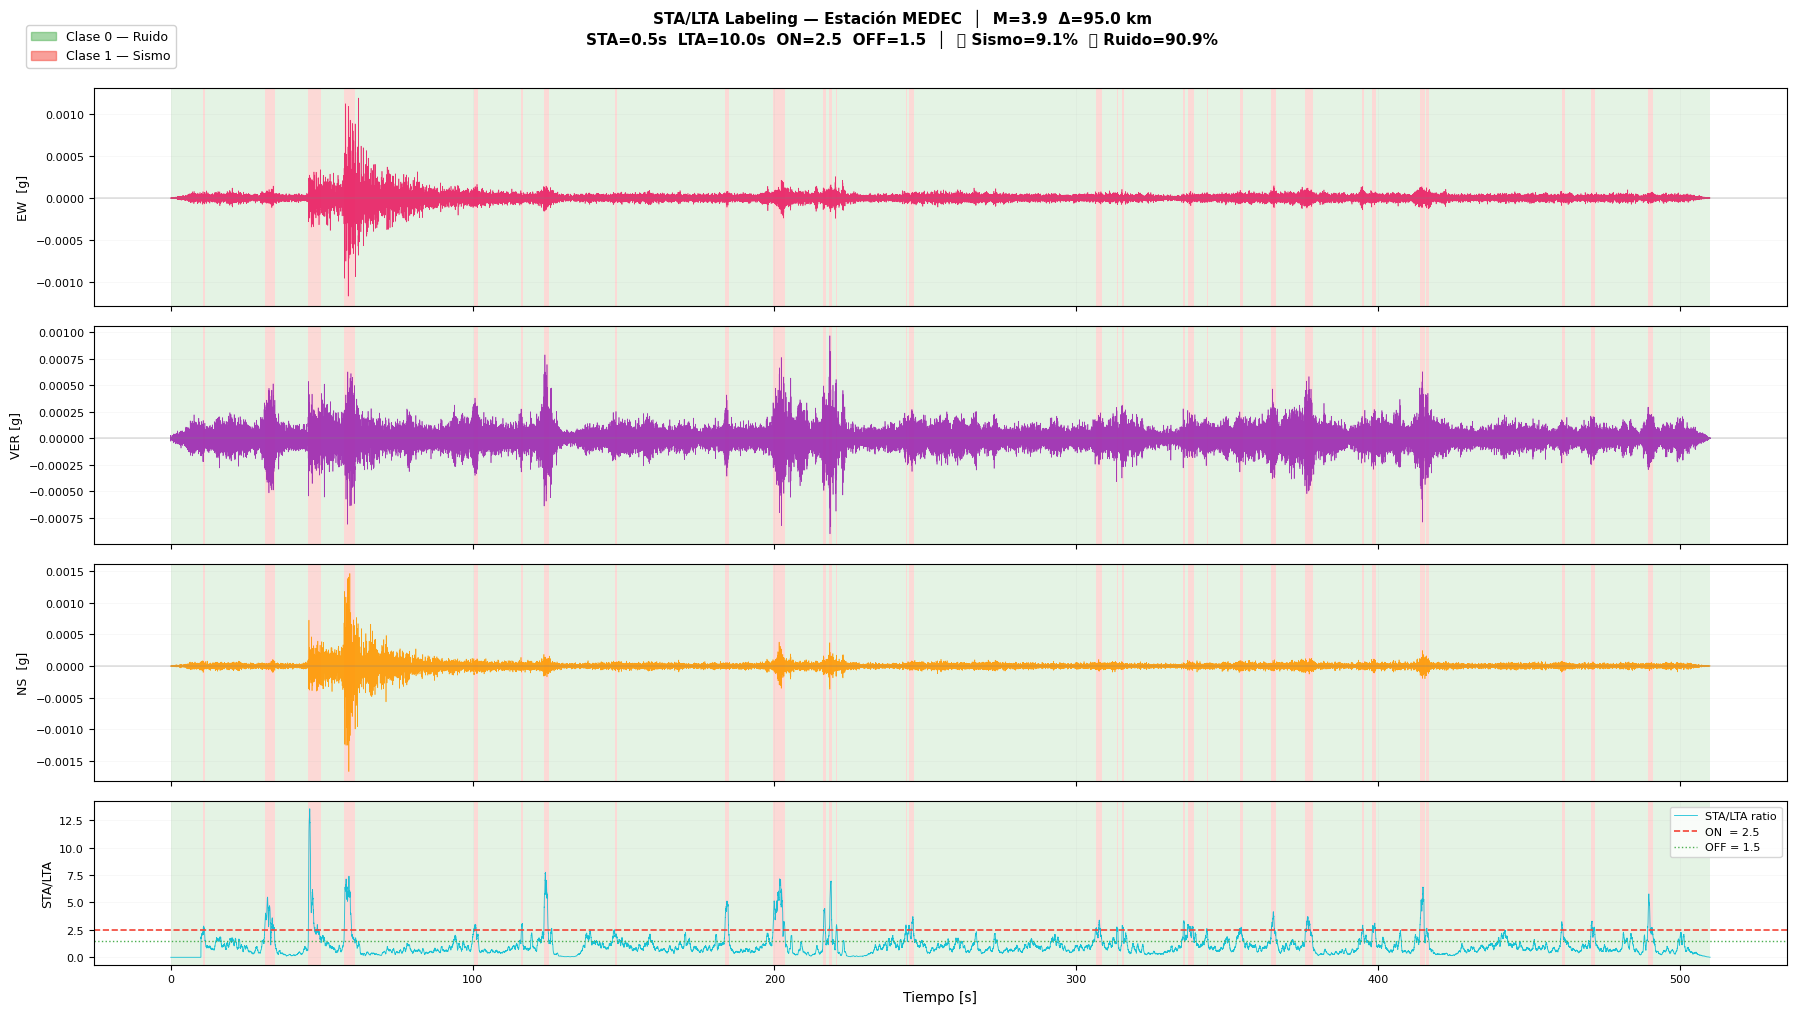

In [9]:
def plot_sta_lta_validation(data_g, cft, is_sismo, events, meta,
                             fs=FS, fmax_cft=None,
                             zoom_start_s=None, zoom_end_s=None,
                             figsize=(18, 10)):
    """
    Grafica los 3 canales sísmicos + la Characteristic Function del STA/LTA.
    Colorea el fondo:  VERDE=Ruido  ROJO=Sismo.

    Parameters
    ----------
    zoom_start_s / zoom_end_s : float, opcional
        Si se especifican, hace zoom a ese rango de tiempo.
    """
    t = np.arange(len(data_g)) / fs
    channels = [
        (data_g[:, 0], 'EW  [g]',  '#E91E63'),
        (data_g[:, 1], 'VER [g]',  '#9C27B0'),
        (data_g[:, 2], 'NS  [g]',  '#FF9800'),
    ]

    fig, axes = plt.subplots(4, 1, figsize=figsize, sharex=True,
                              gridspec_kw={'height_ratios': [2, 2, 2, 1.5]})

    mag  = meta.get('magnitud', '?')
    dist = meta.get('dist_epicentral', '?')
    sta  = meta.get('codigo_estacion', '?')
    pct  = 100 * is_sismo.sum() / len(is_sismo)
    fig.suptitle(
        f"STA/LTA Labeling — Estación {sta}  │  M={mag}  Δ={dist} km\n"
        f"STA={STA_SEC}s  LTA={LTA_SEC}s  ON={TRIGGER_ON}  OFF={TRIGGER_OFF}  "
        f"│  🔴 Sismo={pct:.1f}%  🟢 Ruido={100-pct:.1f}%",
        fontsize=11, fontweight='bold', y=1.01
    )

    # ── Construir rangos de zonas para axvspan ─────────────────
    # Zonas rojas: intervalos de eventos disparados
    sismo_ranges = [(i_on / fs, i_off / fs) for i_on, i_off in events]

    # Zonas verdes: complemento (antes del 1° evento, entre eventos, después)
    t_total = t[-1]
    ruido_ranges = []
    prev_end = 0.0
    for t_on, t_off in sismo_ranges:
        if t_on > prev_end:
            ruido_ranges.append((prev_end, t_on))
        prev_end = t_off
    if prev_end < t_total:
        ruido_ranges.append((prev_end, t_total))

    def shade_axes(ax):
        """Aplica coloreado de fondo a un eje."""
        for t0, t1 in ruido_ranges:
            ax.axvspan(t0, t1, alpha=0.15, color='#4CAF50', linewidth=0)
        for t0, t1 in sismo_ranges:
            ax.axvspan(t0, t1, alpha=0.20, color='#F44336', linewidth=0)

    # ── Canales sísmicos (3 subplots) ─────────────────────────
    for ax, (signal, label, color) in zip(axes[:3], channels):
        ax.plot(t, signal, color=color, linewidth=0.45, alpha=0.9, rasterized=True)
        shade_axes(ax)
        ax.set_ylabel(label, fontsize=9)
        ax.axhline(0, color='gray', linewidth=0.3)
        ax.grid(True, alpha=0.15, linewidth=0.4)
        ax.tick_params(labelsize=8)

    # ── Characteristic Function (4° subplot) ──────────────────
    ax_cft = axes[3]
    ax_cft.plot(t, cft, color='#00BCD4', linewidth=0.6, alpha=0.9,
                label='STA/LTA ratio', rasterized=True)
    ax_cft.axhline(TRIGGER_ON,  color='#F44336', linewidth=1.2,
                   linestyle='--', label=f'ON  = {TRIGGER_ON}')
    ax_cft.axhline(TRIGGER_OFF, color='#4CAF50', linewidth=1.0,
                   linestyle=':',  label=f'OFF = {TRIGGER_OFF}')
    shade_axes(ax_cft)
    ax_cft.set_ylabel('STA/LTA', fontsize=9)
    ax_cft.set_xlabel('Tiempo [s]', fontsize=10)
    ax_cft.legend(fontsize=8, loc='upper right', framealpha=0.8)
    ax_cft.grid(True, alpha=0.15, linewidth=0.4)
    ax_cft.tick_params(labelsize=8)
    if fmax_cft:
        ax_cft.set_ylim(0, fmax_cft)

    # ── Leyenda global ─────────────────────────────────────────
    legend_patches = [
        mpatches.Patch(color='#4CAF50', alpha=0.5, label='Clase 0 — Ruido'),
        mpatches.Patch(color='#F44336', alpha=0.5, label='Clase 1 — Sismo'),
    ]
    fig.legend(handles=legend_patches, loc='upper left',
               bbox_to_anchor=(0.01, 1.0), fontsize=9, framealpha=0.9)

    # ── Zoom opcional ──────────────────────────────────────────
    if zoom_start_s is not None and zoom_end_s is not None:
        axes[0].set_xlim(zoom_start_s, zoom_end_s)

    plt.tight_layout()
    plt.show()
    return fig


# ─── Gráfica completa ─────────────────────────────────────────
print("📊 Gráfica completa (señal entera)...")
fig_full = plot_sta_lta_validation(data_sgc, cft_sgc, is_sismo_sgc,
                                    events_sgc, meta_sgc)

🔍 Zoom: evento principal [45.6s → 49.7s] ± 30.0s


/tmp/ipykernel_7629/3048030591.py:95: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7629/3048030591.py:95: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


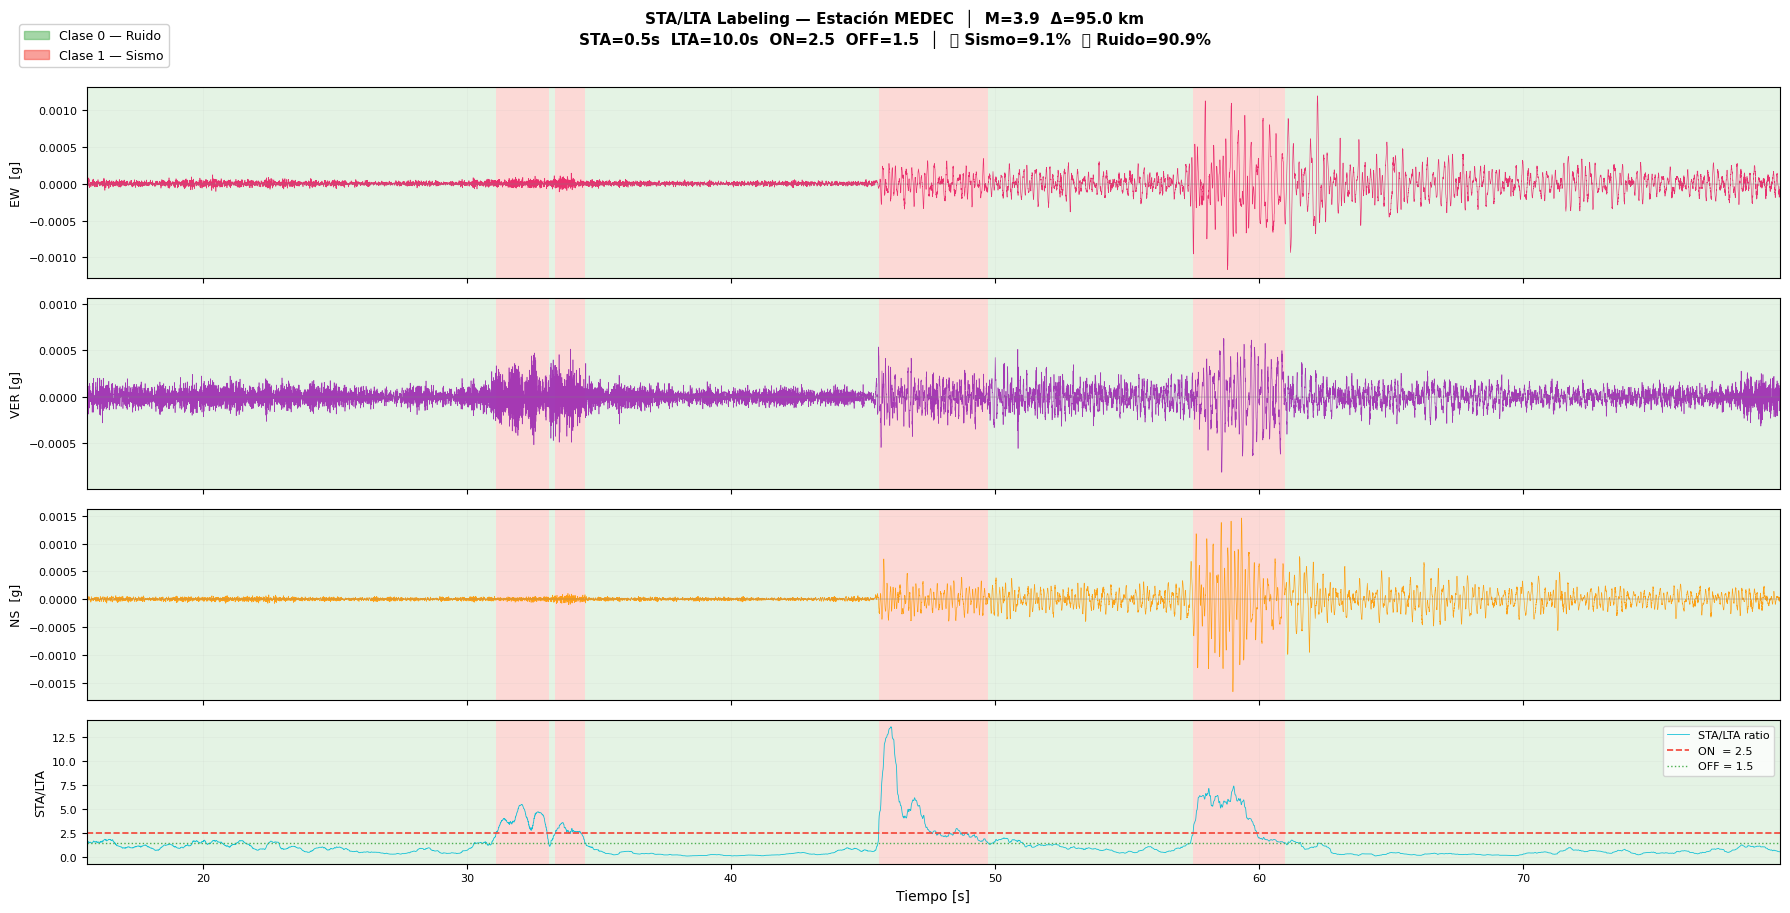

In [10]:
# ─── Zoom automático al onset del evento principal ───────────
# Busca el evento con mayor duración y muestra ±30s a su alrededor
if events_sgc:
    longest_event = max(events_sgc, key=lambda e: e[1] - e[0])
    t_peak_on  = longest_event[0] / FS
    t_peak_off = longest_event[1] / FS
    zoom_margin = 30.0  # segundos antes y después
    z_start = max(0, t_peak_on  - zoom_margin)
    z_end   = min(t_sgc[-1], t_peak_off + zoom_margin)

    print(f"🔍 Zoom: evento principal [{t_peak_on:.1f}s → {t_peak_off:.1f}s] ± {zoom_margin}s")
    fig_zoom = plot_sta_lta_validation(
        data_sgc, cft_sgc, is_sismo_sgc, events_sgc, meta_sgc,
        zoom_start_s=z_start, zoom_end_s=z_end,
        figsize=(18, 9)
    )
else:
    print("⚠️  Ningún evento detectado. Prueba reducir TRIGGER_ON en la celda 0.")

## 5 — Funciones Auxiliares: Augmentation, Windowing y Espectrogramas

In [11]:
def add_gaussian_noise(data_g, sigma_dict, n_copies=N_AUGMENTED, rng_seed=None):
    """Genera n_copies réplicas de data_g con ruido Gaussiano por eje."""
    rng    = np.random.default_rng(rng_seed)
    sigmas = np.array([sigma_dict['x'], sigma_dict['y'], sigma_dict['z']], dtype=np.float32)
    return [
        (data_g + rng.normal(0, sigmas, size=data_g.shape).astype(np.float32))
        for _ in range(n_copies)
    ]


def sliding_windows(data, win_samples=WIN_SAMPLES, stride=STRIDE_SAMPLES):
    """Segmenta data (N, C) en ventanas deslizantes. Devuelve list de (win, int start_idx)."""
    result = []
    n = len(data)
    start = 0
    while start + win_samples <= n:
        result.append((data[start : start + win_samples], start))
        start += stride
    return result


def compute_spectrogram(window, fs=FS, nperseg=NPERSEG, noverlap=NOVERLAP):
    """
    Calcula el espectrograma 3-canal de una ventana.
    Returns: (freq_bins, time_bins, 3) float32 en escala log₁₀.
    """
    specs = []
    for ch in range(window.shape[1]):
        _, _, Sxx = spectrogram(
            window[:, ch].astype(np.float64),
            fs=fs, nperseg=nperseg, noverlap=noverlap,
            scaling='density', window='hann'
        )
        specs.append(np.log10(Sxx + 1e-12).astype(np.float32))
    return np.stack(specs, axis=-1)  # (freq, time, 3)


def classify_window(start_idx, is_sismo_mask,
                    win_samples=WIN_SAMPLES, overlap_thr=TRIGGER_OVERLAP):
    """
    Clasifica una ventana según el porcentaje de muestras sísmicas.

    Returns
    -------
    1  → 1_Sismo  (fracción sísmicas ≥ overlap_thr)
    0  → 0_Ruido
    """
    segment = is_sismo_mask[start_idx : start_idx + win_samples]
    return 1 if segment.mean() >= overlap_thr else 0


print("✅ Funciones auxiliares cargadas.")

✅ Funciones auxiliares cargadas.


## 6 — Pipeline de Exportación Inteligente

In [12]:
def create_dataset_dirs(clean=False):
    """Crea (y opcionalmente limpia) la estructura del dataset."""
    if clean:
        import shutil
        if DATASET_ROOT.exists():
            shutil.rmtree(DATASET_ROOT)
            print(f"🗑️  Dataset anterior eliminado.")
    DIR_RUIDO.mkdir(parents=True, exist_ok=True)
    DIR_SISMO.mkdir(parents=True, exist_ok=True)
    print(f"📁 Dataset/\n   ├── 0_Ruido/\n   └── 1_Sismo/")


def process_bin_file(bin_path, out_dir=DIR_RUIDO, prefix='noise'):
    """
    Pipeline .bin → 0_Ruido.
    El ruido del sensor es siempre Clase 0 (no se necesita STA/LTA).
    """
    stem   = Path(bin_path).stem
    _, data = parse_bin(bin_path)
    wins   = sliding_windows(data[:, 1:])  # excluye columna de tiempo
    saved  = 0
    for idx, (win, _) in enumerate(wins):
        spec  = compute_spectrogram(win)
        fname = out_dir / f"{prefix}_{stem}_w{idx:04d}.npy"
        np.save(str(fname), spec)
        saved += 1
    print(f"  [BIN] {Path(bin_path).name:<38} 0_Ruido → {saved:4d} espectrogramas")
    return saved


def process_anc_file(anc_path, sigma_dict,
                      n_augmented=N_AUGMENTED, prefix='sgc'):
    """
    Pipeline .anc con etiquetado inteligente por STA/LTA.

    Lógica de exportación:
      - Corre STA/LTA sobre la señal ORIGINAL (sin ruido añadido).
      - Clasifica cada ventana en Clase 0 ó Clase 1.
      - Aplica la MISMA máscara a la señal original Y a las copias aumentadas.
        (La aumentación no cambia la clase; solo varía el nivel de ruido.)

    Returns
    -------
    dict: {'0_Ruido': n, '1_Sismo': n, 'eventos': n_events}
    """
    stem   = Path(anc_path).stem
    meta, data_g = parse_anc(anc_path)

    # ── STA/LTA sobre señal original ──────────────────────────
    cft, is_sismo, events = aplicar_sta_lta(data_g)

    # ── Construir lista de señales a exportar ─────────────────
    # La señal original siempre se incluye
    all_signals = [('orig', data_g)]
    aug_signals = add_gaussian_noise(data_g, sigma_dict,
                                      n_copies=n_augmented,
                                      rng_seed=hash(stem) % (2**31))
    for k, aug in enumerate(aug_signals, start=1):
        all_signals.append((f'aug{k}', aug))

    stats = {'0_Ruido': 0, '1_Sismo': 0, 'eventos': len(events)}

    for tag, signal in all_signals:
        wins = sliding_windows(signal)
        for win_idx, (win, start_idx) in enumerate(wins):
            label    = classify_window(start_idx, is_sismo)
            out_dir  = DIR_SISMO if label == 1 else DIR_RUIDO
            cls_tag  = '1S' if label == 1 else '0R'
            fname    = out_dir / f"sgc_{stem}_{tag}_{cls_tag}_w{win_idx:04d}.npy"
            spec     = compute_spectrogram(win)
            np.save(str(fname), spec)
            key = '1_Sismo' if label == 1 else '0_Ruido'
            stats[key] += 1

    mag  = meta.get('magnitud', '?')
    dist = meta.get('dist_epicentral', '?')
    print(
        f"  [ANC] {Path(anc_path).name:<30}  M={mag} Δ={dist}km  "
        f"│ evts={stats['eventos']:2d}  "
        f"0_Ruido={stats['0_Ruido']:4d}  1_Sismo={stats['1_Sismo']:4d}"
    )
    return stats


# ── Crear directorios ─────────────────────────────────────────
create_dataset_dirs(clean=True)

🗑️  Dataset anterior eliminado.
📁 Dataset/
   ├── 0_Ruido/
   └── 1_Sismo/


In [13]:
# ─── Procesar archivos de ejemplo ────────────────────────────
print("\n🚀 Procesando archivos de ejemplo...\n")

n_bin  = process_bin_file(BIN_FILE)
st_anc = process_anc_file(ANC_FILE, noise_sigma)

total_0 = n_bin + st_anc['0_Ruido']
total_1 = st_anc['1_Sismo']

print(f"\n{'═'*55}")
print(f"  ✅ Dataset generado con etiquetado STA/LTA")
print(f"     0_Ruido : {total_0:6d} espectrogramas  (sensor + silencio SGC)")
print(f"     1_Sismo : {total_1:6d} espectrogramas  (evento real + aumentado)")
print(f"     Total   : {total_0+total_1:6d} espectrogramas")
print(f"     Ratio   : 1:{total_0/max(total_1,1):.1f}  (Sismo : Ruido)")
print(f"{'═'*55}")


🚀 Procesando archivos de ejemplo...

  [BIN] accel_20260502_001141.bin              0_Ruido →   57 espectrogramas
  [ANC] SGC2026hpmsib_MEDEC_10.anc      M=3.9 Δ=95.0km  │ evts=33  0_Ruido=1732  1_Sismo= 296

═══════════════════════════════════════════════════════
  ✅ Dataset generado con etiquetado STA/LTA
     0_Ruido :   1789 espectrogramas  (sensor + silencio SGC)
     1_Sismo :    296 espectrogramas  (evento real + aumentado)
     Total   :   2085 espectrogramas
     Ratio   : 1:6.0  (Sismo : Ruido)
═══════════════════════════════════════════════════════


## 7 — Verificación Visual del Dataset


📂 /home/pinpa/Documents/Universidad/Trabajo_de_Grado_Seismology/PANdeMaiz/Data_Labeling/Dataset
  0_Ruido        1789 archivos   shape=(65, 11, 3)
  1_Sismo         296 archivos   shape=(65, 11, 3)
  TOTAL          2085 archivos


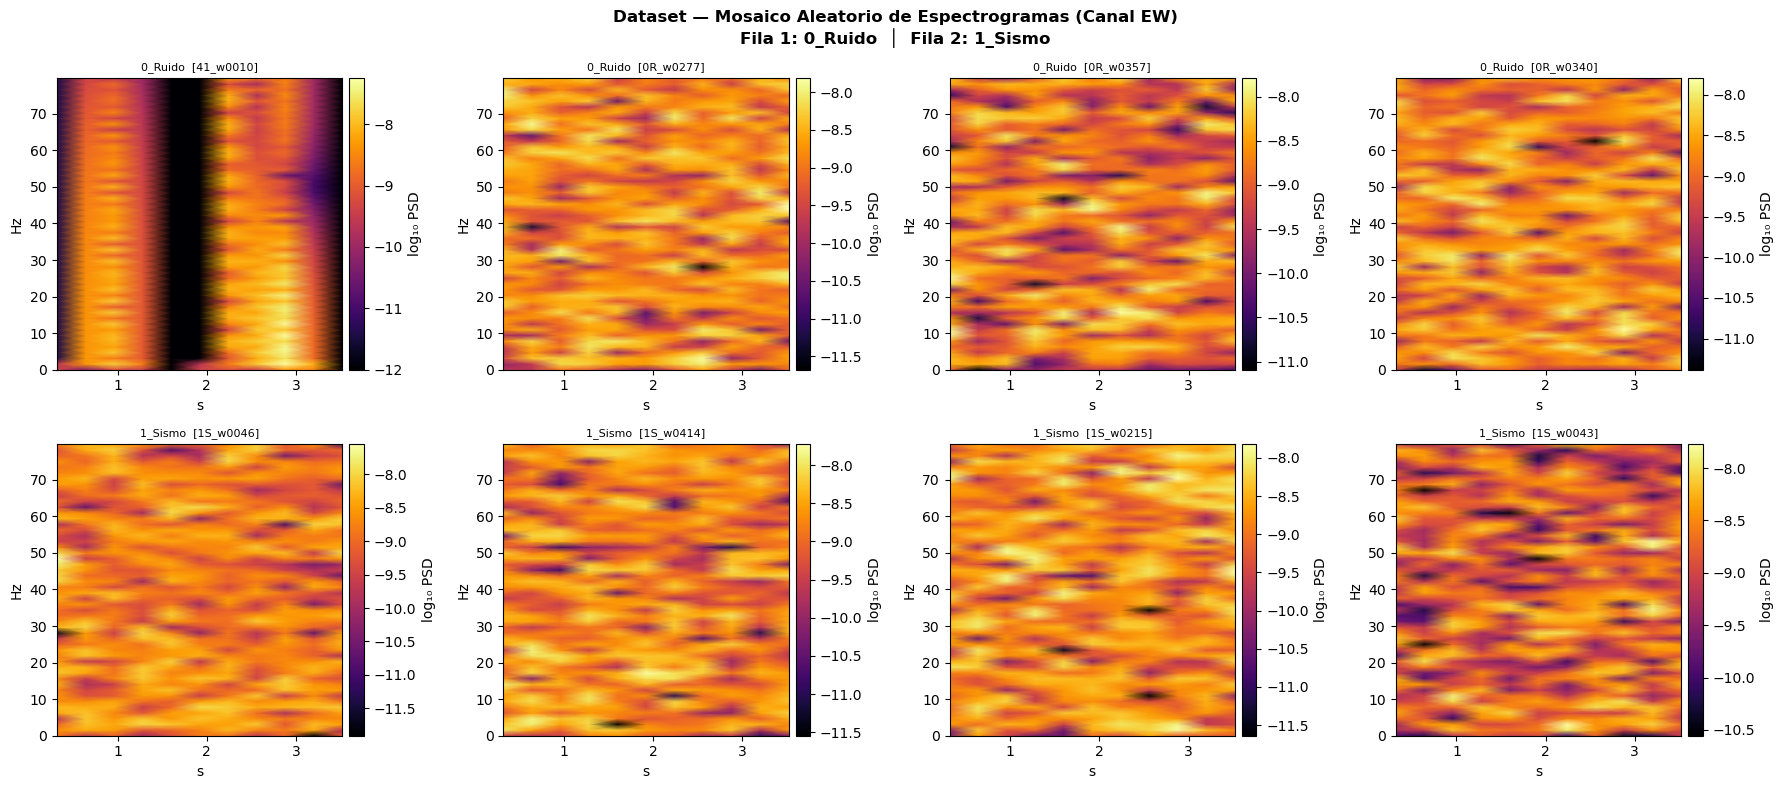

In [14]:
def dataset_stats(root=DATASET_ROOT):
    """Cuenta archivos y verifica shapes uniformes."""
    print(f"\n📂 {root.resolve()}")
    total = 0
    for cls_dir in sorted(root.glob('*')):
        if not cls_dir.is_dir(): continue
        files = sorted(cls_dir.glob('*.npy'))
        n = len(files)
        total += n
        if n == 0:
            print(f"  {cls_dir.name:<12} {n:6d} archivos  ⚠️  VACÍO")
            continue
        idxs   = np.random.choice(n, min(5, n), replace=False)
        shapes = {np.load(files[i]).shape for i in idxs}
        shape_str = str(shapes.pop()) if len(shapes)==1 else f'⚠️ {shapes}'
        print(f"  {cls_dir.name:<12} {n:6d} archivos   shape={shape_str}")
    print(f"  {'TOTAL':<12} {total:6d} archivos")
    return total


dataset_stats()

# ── Mosaico comparativo ───────────────────────────────────────
f_ref, t_ref, _ = spectrogram(
    np.zeros(WIN_SAMPLES), fs=FS, nperseg=NPERSEG, noverlap=NOVERLAP
)
f_mask = f_ref <= FMAX

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle(
    'Dataset — Mosaico Aleatorio de Espectrogramas (Canal EW)\n'
    'Fila 1: 0_Ruido  │  Fila 2: 1_Sismo',
    fontweight='bold'
)

for row, cls_dir in enumerate([DIR_RUIDO, DIR_SISMO]):
    files  = sorted(cls_dir.glob('*.npy'))
    chosen = np.random.choice(len(files), min(4, len(files)), replace=False)
    for col, idx in enumerate(chosen):
        spec = np.load(files[idx])           # (freq, time, 3)
        ax_p = axes[row, col]
        im   = ax_p.pcolormesh(
            t_ref, f_ref[f_mask],
            spec[f_mask, :, 0],
            shading='gouraud', cmap='inferno'
        )
        ax_p.set_title(f'{cls_dir.name}  [{files[idx].stem[-8:]}]', fontsize=8)
        ax_p.set_ylabel('Hz')
        ax_p.set_xlabel('s')
        fig.colorbar(im, ax=ax_p, label='log₁₀ PSD', pad=0.02)

plt.tight_layout()
plt.show()

## 8 — Escalabilidad: Procesamiento en Lote con `glob`

Coloca todos tus archivos en `raw_data/` y ejecuta esta celda.
La σ de ruido se estima desde el **primer** `.bin` disponible y se reutiliza para todos los `.anc`.

In [15]:
RAW_DATA_DIR = Path('raw_data')

bin_files = sorted(glob.glob(str(RAW_DATA_DIR / '**' / '*.bin'), recursive=True))
anc_files = sorted(glob.glob(str(RAW_DATA_DIR / '**' / '*.anc'), recursive=True))

print(f"📂 {RAW_DATA_DIR.resolve()}")
print(f"   .bin : {len(bin_files)} archivos")
print(f"   .anc : {len(anc_files)} archivos")

if not bin_files and not anc_files:
    print("\n⚠️  No se encontraron archivos en raw_data/")
    print("   Estructura esperada:")
    print("   raw_data/")
    print("   ├── ruido/    ← archivos .bin del ADXL345")
    print("   └── sismos/   ← archivos .anc del SGC")
else:
    # ── Estimar σ de ruido ────────────────────────────────────
    if bin_files:
        print(f"\n🔍 Referencia σ: {Path(bin_files[0]).name}")
        _, ref_data    = parse_bin(bin_files[0])
        batch_sigma    = estimate_noise_sigma(ref_data)
    else:
        print("⚠️  Sin .bin — usando σ del ejemplo cargado en memoria.")
        batch_sigma = noise_sigma

    # ── Recrear dataset limpio ────────────────────────────────
    create_dataset_dirs(clean=True)

    # ── Procesar .bin ─────────────────────────────────────────
    totals = {'0_Ruido': 0, '1_Sismo': 0, 'errores': 0}

    if bin_files:
        print(f"\n{'─'*60}")
        print(f"Procesando {len(bin_files)} archivo(s) .bin  →  0_Ruido")
        print(f"{'─'*60}")
        for fp in bin_files:
            try:
                n = process_bin_file(fp)
                totals['0_Ruido'] += n
            except Exception as e:
                print(f"  ⚠️  {Path(fp).name}: {e}")
                totals['errores'] += 1

    # ── Procesar .anc con STA/LTA ─────────────────────────────
    if anc_files:
        print(f"\n{'─'*60}")
        print(f"Procesando {len(anc_files)} archivo(s) .anc  →  STA/LTA labeling")
        print(f"Umbral ON={TRIGGER_ON}  OFF={TRIGGER_OFF}  overlap={TRIGGER_OVERLAP*100:.0f}%")
        print(f"{'─'*60}")
        for fp in anc_files:
            try:
                st = process_anc_file(fp, batch_sigma, n_augmented=N_AUGMENTED)
                totals['0_Ruido'] += st['0_Ruido']
                totals['1_Sismo'] += st['1_Sismo']
            except Exception as e:
                print(f"  ⚠️  {Path(fp).name}: {e}")
                totals['errores'] += 1

    # ── Resumen ───────────────────────────────────────────────
    grand_total = totals['0_Ruido'] + totals['1_Sismo']
    print(f"\n{'═'*60}")
    print(f"  ✅ PIPELINE COMPLETADO (STA/LTA v2)")
    print(f"     0_Ruido  : {totals['0_Ruido']:7,} espectrogramas")
    print(f"     1_Sismo  : {totals['1_Sismo']:7,} espectrogramas")
    print(f"     Total    : {grand_total:7,} espectrogramas")
    if totals['1_Sismo'] > 0:
        print(f"     Ratio    :  1 : {totals['0_Ruido']/totals['1_Sismo']:.1f}  (Sismo : Ruido)")
    if totals['errores']:
        print(f"     Errores  : {totals['errores']}  (ver mensajes ⚠️ arriba)")
    print(f"{'═'*60}")
    dataset_stats()

📂 /home/pinpa/Documents/Universidad/Trabajo_de_Grado_Seismology/PANdeMaiz/Data_Labeling/raw_data
   .bin : 1 archivos
   .anc : 1 archivos

🔍 Referencia σ: accel_20260502_001141.bin
🔍 Piso de Ruido (σ sensor):  X=0.000496g  Y=0.000683g  Z=0.001320g  │  σ̄=0.000833g
🗑️  Dataset anterior eliminado.
📁 Dataset/
   ├── 0_Ruido/
   └── 1_Sismo/

────────────────────────────────────────────────────────────
Procesando 1 archivo(s) .bin  →  0_Ruido
────────────────────────────────────────────────────────────
  [BIN] accel_20260502_001141.bin              0_Ruido →   57 espectrogramas

────────────────────────────────────────────────────────────
Procesando 1 archivo(s) .anc  →  STA/LTA labeling
Umbral ON=2.5  OFF=1.5  overlap=30%
────────────────────────────────────────────────────────────
  [ANC] SGC2026hpmsib_MEDEC_10.anc      M=3.9 Δ=95.0km  │ evts=33  0_Ruido=1732  1_Sismo= 296

════════════════════════════════════════════════════════════
  ✅ PIPELINE COMPLETADO (STA/LTA v2)
     0_Ruido  : 